In [5]:
from m_g_k import NServerQueue, Server
import matplotlib.pyplot as plt
import numpy.random as rng
import numpy as np
import scipy.stats as stats


In [ ]:
class ModelConfig:
    def __init__(self, servers, arrival_generator, label):
        self.servers = servers
        self.arrival_generator = arrival_generator
        self.label = label

model_config_1 = ModelConfig(
    servers=[
        Server(lambda: rng.exponential(1/2), lambda: 1),
        Server(lambda: rng.exponential(1/2), lambda: 2),
        Server(lambda: rng.exponential(1/2), lambda: 3),
    ],
    arrival_generator=lambda: rng.exponential(1/6),
    label="Model 1: 3 servers, arrival rate 6"
)
model_config_2 = ModelConfig(
    servers=[
        Server(lambda: rng.exponential(1/2), lambda: 1),
        Server(lambda: rng.exponential(1/2), lambda: 2),
        Server(lambda: rng.exponential(1/2), lambda: 3),
    ],
    arrival_generator=lambda: rng.exponential(1/6),
    label="Model 1: 3 servers, arrival rate 6"
)

SIMULATION_LENGTH = 60 * 8
CONFIDENCE_LEVEL = 0.95
ACCEPTED_ERROR = 1/3

In [7]:
def perform_simulations(amount: int, model_config: ModelConfig) -> list[NServerQueue]:
    simulations = []
    for i in range(amount):
        model = NServerQueue(
            servers=model_config.servers,
            arrival_generator=model_config.arrival_generator,
            end_time=SIMULATION_LENGTH,
        )
        model.run()
        simulations.append(model)

    return simulations

def get_wait_time_stats(simulation_amount: int, model_config: ModelConfig) -> list[float]:
    wait_time_averages = []
    for i in range(simulation_amount):
        model = NServerQueue(
            servers=model_config.servers,
            arrival_generator=model_config.arrival_generator,
            end_time=SIMULATION_LENGTH,
        )
        model.run()
        wait_time_averages += [np.mean(get_wait_times(model))]

    return wait_time_averages

def get_wait_times(model: NServerQueue):
    wait_times = [v + model.time_in_queue[k] for k, v in model.time_in_service.items()]
    return wait_times

def get_average_waiting_time(wait_times: list[float]):
    return sum(wait_times) / len(wait_times) if wait_times else 0

def get_variance_waiting_time(avg: float, wait_times: list[float]):
    return sum((x - avg) ** 2 for x in wait_times) / (len(wait_times) - 1) if wait_times else 0

class AverageWaitTimeAnalysis:
    def __init__(self, average: float, stdev: float, error_bound: float, sample_size: int, sample: list[float]):
        self.average = average
        self.stdev = stdev
        self.error_bound = error_bound
        self.sample_size = sample_size
        self.sample = sample
    
    def __str__(self):
        return (f"Where X is the average wait time of customers in a day\n"
                f"Mean of X: {self.average:.2f}\n"
                f"Variance of X: {self.stdev:.2f}\n"
                f"Error Bound: {self.error_bound:.2f}\n"
                f"Sample Size: {self.sample_size}")

def analyze_average_wait_time(model_config: ModelConfig, accepted_error: float, confidence_level: float) -> AverageWaitTimeAnalysis:
    z_value = stats.norm.ppf((1 + confidence_level) / 2)
    def get_error_bound(stdev: float, sample_size: int):
        return 2 * z_value * (stdev / (sample_size ** 0.5))

    wait_times = get_wait_time_stats(500, model_config)
    avg_avg_wait_time = np.mean(wait_times)
    std_avg_wait_time = np.std(wait_times)
    error_bound = get_error_bound(std_avg_wait_time, len(wait_times))

    while error_bound > accepted_error:
        print(f"Error bound is too large: {error_bound:.2f} > {accepted_error:.2f}, running more simulations...")
        
        wait_times += get_wait_time_stats(100, model_config)
        avg_avg_wait_time = np.mean(wait_times) 
        std_avg_wait_time = np.std(wait_times)
        error_bound = get_error_bound(std_avg_wait_time, len(wait_times))

    return AverageWaitTimeAnalysis(
        average=avg_avg_wait_time,
        stdev=std_avg_wait_time,
        error_bound=error_bound,
        sample_size=len(wait_times),
        sample=wait_times,
    )

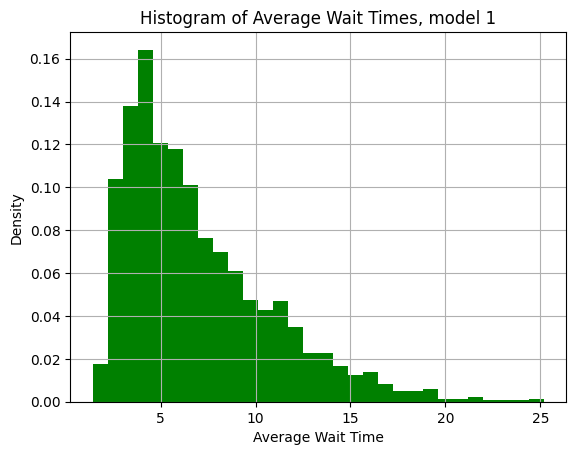

In [ ]:
data_1 = analyze_average_wait_time(model_config_1, ACCEPTED_ERROR, CONFIDENCE_LEVEL)

plt.hist(data_1.sample, bins=30, color='g', density=True)

plt.title('Histogram of Average Wait Times, model 1')
plt.xlabel('Average Wait Time')
plt.ylabel('Density')
plt.grid()
plt.show()

Error bound is too large: 0.69 > 0.33, running more simulations...
Error bound is too large: 0.63 > 0.33, running more simulations...
Error bound is too large: 0.59 > 0.33, running more simulations...
Error bound is too large: 0.55 > 0.33, running more simulations...
Error bound is too large: 0.53 > 0.33, running more simulations...
Error bound is too large: 0.50 > 0.33, running more simulations...
Error bound is too large: 0.48 > 0.33, running more simulations...
Error bound is too large: 0.45 > 0.33, running more simulations...
Error bound is too large: 0.43 > 0.33, running more simulations...
Error bound is too large: 0.42 > 0.33, running more simulations...
Error bound is too large: 0.40 > 0.33, running more simulations...
Error bound is too large: 0.39 > 0.33, running more simulations...
Error bound is too large: 0.37 > 0.33, running more simulations...
Error bound is too large: 0.36 > 0.33, running more simulations...
Error bound is too large: 0.35 > 0.33, running more simulation

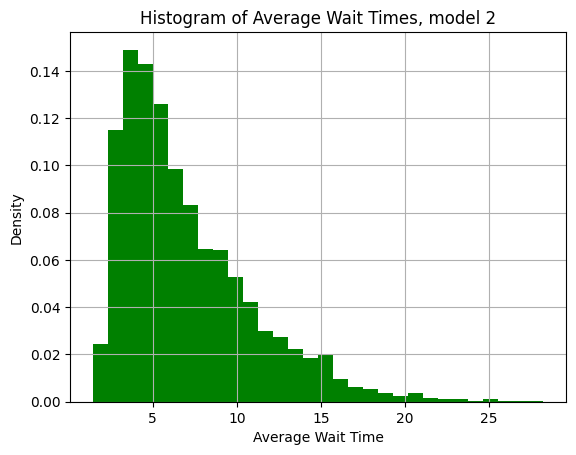

In [11]:
data_2 = analyze_average_wait_time(model_config_1, ACCEPTED_ERROR, CONFIDENCE_LEVEL)

plt.hist(data_2.sample, bins=30, color='g', density=True)

plt.title('Histogram of Average Wait Times, model 2')
plt.xlabel('Average Wait Time')
plt.ylabel('Density')
plt.grid()
plt.show()

Z Statistic: -0.24
Critical Value: 1.96


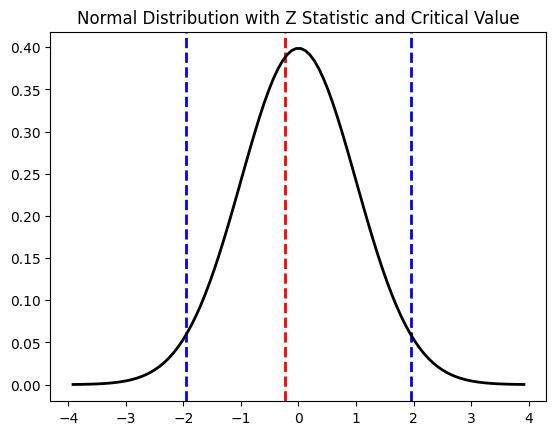

In [ ]:
def calculate_z_statistic(avg1, var1, n1, avg2, var2, n2):
    return (avg1 - avg2) / (var1 / n1 + var2 / n2) ** 0.5

def calculate_critical_value(confidence_level: float):
    return stats.norm.ppf((1 + confidence_level) / 2)

def plot_normal_distribution(z_statistic: float, critical_value: float):
    plt.axvline(z_statistic, color='r', linestyle='dashed', linewidth=2)
    plt.axvline(critical_value, color='b', linestyle='dashed', linewidth=2)
    plt.axvline(-critical_value, color='b', linestyle='dashed', linewidth=2)
    x = np.linspace(-critical_value*2, critical_value*2, 100)
    p = stats.norm.pdf(x, 0, 1)
    plt.plot(x, p, 'k', linewidth=2)
    plt.title('Normal Distribution with Z Statistic and Critical Value')
    plt.show()

mean_1 = data_1.average
stdev_1 = data_1.stdev
sample_size_1 = data_1.sample_size

mean_2 = data_2.average
stdev_2 = data_2.stdev
sample_size_2 = data_2.sample_size

z_statistic = calculate_z_statistic(mean_1, stdev_1**2, sample_size_1, mean_2, stdev_2, sample_size_2)
critical_value = calculate_critical_value(CONFIDENCE_LEVEL)
print(f"Z Statistic: {z_statistic:.2f}")
print(f"Critical Value: {critical_value:.2f}")
if abs(z_statistic) > critical_value:
    print("The two models are significantly different.")

plot_normal_distribution(z_statistic, critical_value)


In [12]:

model_config_1 = ModelConfig(
    servers=[
        Server(lambda: rng.exponential(1/2), lambda: 1),
        Server(lambda: rng.exponential(1/2), lambda: 2),
        Server(lambda: rng.exponential(1/2), lambda: 3),
    ],
    arrival_generator=lambda: rng.exponential(1/6),
    label="Model 1: 2 servers, arrival rate 6"
)
model_config_2 = ModelConfig(
    servers=[
        Server(lambda: rng.exponential(1/6), lambda: 1),
    ],
    arrival_generator=lambda: rng.exponential(1/6),
    label="Model 1: 2 servers, arrival rate 6"
)

SIMULATION_LENGTH = 60 * 8
CONFIDENCE_LEVEL = 0.95
ACCEPTED_ERROR = 1/3

Error bound is too large: 0.69 > 0.33, running more simulations...
Error bound is too large: 0.62 > 0.33, running more simulations...
Error bound is too large: 0.57 > 0.33, running more simulations...
Error bound is too large: 0.54 > 0.33, running more simulations...
Error bound is too large: 0.51 > 0.33, running more simulations...
Error bound is too large: 0.48 > 0.33, running more simulations...
Error bound is too large: 0.47 > 0.33, running more simulations...
Error bound is too large: 0.45 > 0.33, running more simulations...
Error bound is too large: 0.43 > 0.33, running more simulations...
Error bound is too large: 0.41 > 0.33, running more simulations...
Error bound is too large: 0.39 > 0.33, running more simulations...
Error bound is too large: 0.38 > 0.33, running more simulations...
Error bound is too large: 0.37 > 0.33, running more simulations...
Error bound is too large: 0.36 > 0.33, running more simulations...
Error bound is too large: 0.35 > 0.33, running more simulation

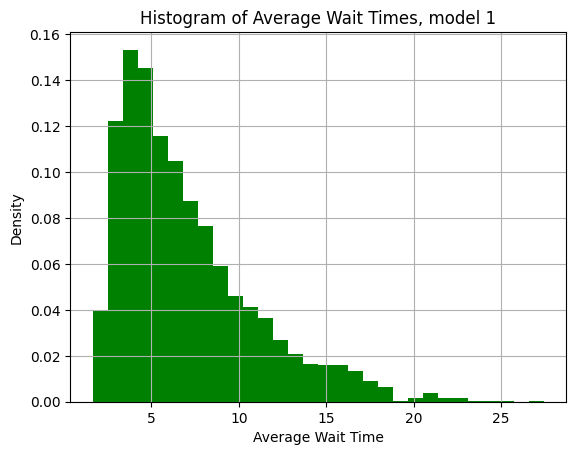

In [13]:

data_1 = analyze_average_wait_time(model_config_1, ACCEPTED_ERROR, CONFIDENCE_LEVEL)

plt.hist(data_1.sample, bins=30, color='g', density=True)

plt.title('Histogram of Average Wait Times, model 1')
plt.xlabel('Average Wait Time')
plt.ylabel('Density')
plt.grid()
plt.show()

Error bound is too large: 0.63 > 0.33, running more simulations...
Error bound is too large: 0.58 > 0.33, running more simulations...
Error bound is too large: 0.54 > 0.33, running more simulations...
Error bound is too large: 0.52 > 0.33, running more simulations...
Error bound is too large: 0.50 > 0.33, running more simulations...
Error bound is too large: 0.47 > 0.33, running more simulations...
Error bound is too large: 0.45 > 0.33, running more simulations...
Error bound is too large: 0.43 > 0.33, running more simulations...
Error bound is too large: 0.41 > 0.33, running more simulations...
Error bound is too large: 0.40 > 0.33, running more simulations...
Error bound is too large: 0.39 > 0.33, running more simulations...
Error bound is too large: 0.37 > 0.33, running more simulations...
Error bound is too large: 0.36 > 0.33, running more simulations...
Error bound is too large: 0.35 > 0.33, running more simulations...
Error bound is too large: 0.34 > 0.33, running more simulation

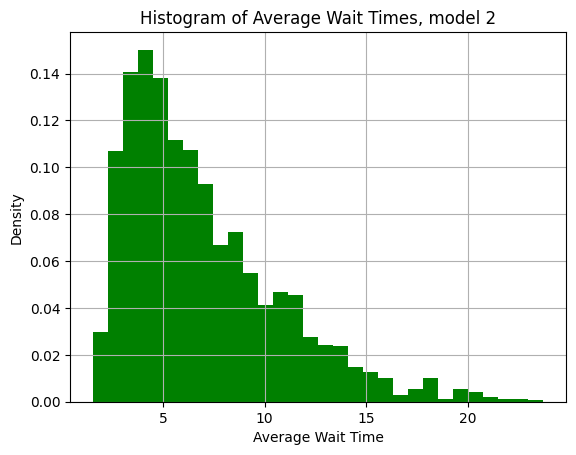

In [14]:
data_2 = analyze_average_wait_time(model_config_1, ACCEPTED_ERROR, CONFIDENCE_LEVEL)

plt.hist(data_2.sample, bins=30, color='g', density=True)

plt.title('Histogram of Average Wait Times, model 2')
plt.xlabel('Average Wait Time')
plt.ylabel('Density')
plt.grid()
plt.show()

Z Statistic: 0.97
Critical Value: 1.96


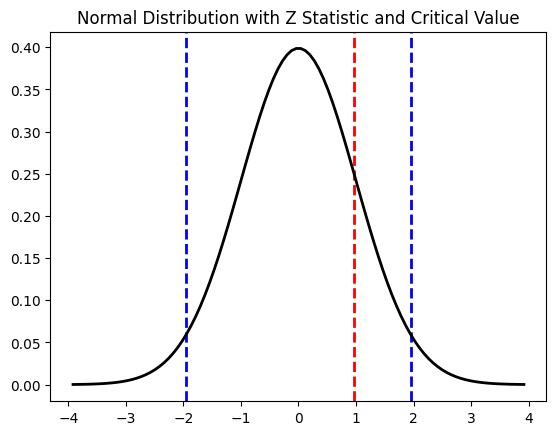

In [ ]:
mean_1 = data_1.average
stdev_1 = data_1.stdev
sample_size_1 = data_1.sample_size

mean_2 = data_2.average
stdev_2 = data_2.stdev
sample_size_2 = data_2.sample_size

z_statistic = calculate_z_statistic(mean_1, stdev_1**2, sample_size_1, mean_2, stdev_2, sample_size_2)
critical_value = calculate_critical_value(CONFIDENCE_LEVEL)
print(f"Z Statistic: {z_statistic:.2f}")
print(f"Critical Value: {critical_value:.2f}")
if abs(z_statistic) > critical_value:
    print("The two models are significantly different.")

plot_normal_distribution(z_statistic, critical_value)